In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langchain_huggingface.embeddings import HuggingFaceEndpointEmbeddings
from langgraph.graph import StateGraph,START,END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [3]:
load_dotenv()

True

In [4]:
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")


In [5]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [6]:
len(docs)

392

In [7]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [8]:
embeddings = HuggingFaceEndpointEmbeddings(
    model="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = FAISS.from_documents(chunks,embeddings)

d:\project_chatbot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
vector_store

In [14]:
retriever = vector_store.as_retriever(search_type = 'similarity',kwargs=3)

In [20]:
docs = retriever.invoke("what is the decision tree")
text = "\n\n".join(doc.page_content for doc in docs)
print(text)

predictions on the training data; we did not restrict the complexity of the tree, so it
learned the whole dataset by heart. However, once we leave the data range for which
the model has data, the model simply keeps predicting the last known point. The tree
has no ability to generate “new” responses, outside of what was seen in the training
data. This shortcoming applies to all models based on trees.9
Strengths, weaknesses, and parameters
As discussed earlier, the parameters that control model complexity in decision trees
are the pre-pruning parameters that stop the building of the tree before it is fully
developed. Usually, picking one of the pre-pruning strategies—setting either
82 | Chapter 2: Supervised Learning

Figure 2-24. Decision boundary of tree with depth 1 (left) and corresponding tree (right)
Figure 2-25. Decision boundary of tree with depth 2 (left) and corresponding decision
tree (right)
This recursive process yields a binary tree of decisions, with each node containing a

In [21]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool:when the user asks financial / conceptual questions
    that might be answered from the stored documents."""

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query':query,
        'context':context,
        'metadata':metadata
    }

In [22]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [23]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]


In [24]:
def chat_node(state:ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages':[response]}

In [25]:
tool_node = ToolNode(tools)

In [26]:
graph =StateGraph(ChatState)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)

graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge('tools','chat_node')

chatbot = graph.compile()

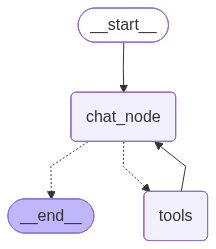

In [27]:
chatbot

In [31]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content="Using the pdf notes, explain how to split a node in a decision tree"
            )
        ]
    }
)

In [33]:
print(result['messages'][-1].content)

The process of splitting a node in a decision tree involves recursively partitioning the data based on the most informative test. The algorithm searches over all possible tests and selects the one that best separates the data points. Each test concerns only a single feature, and the regions in the resulting partition always have axis-parallel boundaries. The recursive partitioning continues until each region in the partition (each leaf in the decision tree) contains only a single target value, which is called pure. 

To split a node, the algorithm follows these steps:

1. Search over all possible tests and find the one that is most informative about the target variable.
2. Split the dataset based on the selected test.
3. Assign data points to the left or right node based on whether the test is true or false.
4. Repeat the process recursively until each region in the partition is pure.

The decision tree can be used for both classification and regression tasks. In classification, the ou